## EDA: A/B-тестирование лендинга

### Описание проекта

В рамках проекта проводится анализ результатов A/B-теста, целью которого является оценка эффективности новой версии лендинга.

Пользователи были случайным образом распределены между двумя экспериментальными группами:

- **Control** — пользователи, взаимодействовавшие с текущей версией лендинга;
- **Treatment** — пользователи, взаимодействовавшие с новой версией лендинга.

Датасет содержит информацию о характеристиках пользователей, их взаимодействии с сайтом и результате целевого действия.

На первом этапе проводится **Exploratory Data Analysis (EDA)** — исследование структуры, качества и основных закономерностей в данных перед проведением статистического анализа A/B-теста.

### Задачи исследования

В рамках EDA необходимо:

1. изучить структуру и характеристики исходных данных;
2. проверить данные на пропуски, дубликаты и некорректные значения;
3. оценить распределение пользователей между экспериментальными группами;
4. проверить сопоставимость групп по основным характеристикам пользователей;
5. исследовать Conversion Rate и его распределение по ключевым сегментам;
6. проанализировать поведенческие характеристики пользователей;
7. рассчитать основные бизнес-метрики.


### Импорт всех необходимых библиотек и загрузка файла

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Загрузка данных эксперимента 
df = pd.read_csv('AB Testing Data.csv')

### Первичный анализ и проверка качества данных

На первом этапе проводится базовая проверка датасета:

- изучение структуры и типов данных;
- просмотр основных статистических характеристик;
- проверка наличия пропущенных значений;
- проверка дубликатов;
- проверка уникальности `user_id`;
- оценка распределения пользователей между экспериментальными группами;
- просмотр распределения целевой метрики `converted`.

In [2]:
# Просмотр таблицы

df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


In [3]:
# Определение размера таблицы

df.shape

(294478, 12)

In [4]:
# Вывод общей информации о датасете

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  str    
 1   timestamp         294478 non-null  str    
 2   group             294478 non-null  str    
 3   landing_page      294478 non-null  str    
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  str    
 7   location          294478 non-null  str    
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  str    
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), str(7)
memory usage: 27.0 MB


In [5]:
# Расчёт основной описательной статистики

df.describe()

,converted,age,session_duration,pages_visited,purchase_amount
count,294478.000000,294478.000000,294478.000000,294478.000000,294478.000000
mean,0.149172,31.902084,5.002136,4.019550,5.610490
std,0.356259,9.250043,1.980285,1.965182,15.438006
min,0.000000,18.000000,0.500000,1.000000,0.000000
25%,0.000000,25.000000,3.640000,3.000000,0.000000
50%,0.000000,32.000000,4.990000,4.000000,0.000000
75%,0.000000,38.000000,6.340000,5.000000,0.000000
max,1.000000,65.000000,13.730000,18.000000,269.280000


In [6]:
# Просмотр пропусков

df.isna().sum()

user_id             0
timestamp           0
group               0
landing_page        0
converted           0
age                 0
gender              0
location            0
session_duration    0
pages_visited       0
device_type         0
purchase_amount     0
dtype: int64

In [7]:
# Просмотр дубликатов

df.duplicated().sum()

np.int64(0)

In [8]:
# Проверка наличия повторяющихся user_id.

dup_ids = df['user_id'].duplicated().sum()
print(f'Повторяющихся user_id: {dup_ids}')
print(f'Все user_id уникальны: {dup_ids == 0}')

Повторяющихся user_id: 0
Все user_id уникальны: True


In [9]:
# Проверка количества пользователей в каждой экспериментальной группе.
# Группы должны быть близки по размеру (ожидается деление 50/50)

df['group'].value_counts()

group
treatment    147552
control      146926
Name: count, dtype: int64

In [10]:
# Проверка распределения пользователей по признаку конверсии:
# сколько пользователей совершили целевое действие (1), а сколько нет (0)

df['converted'].value_counts()

converted
0    250550
1     43928
Name: count, dtype: int64

### Проверка корректности данных

In [11]:
# Проверка соответствия экспериментальной группы и версии страницы

# Количество пользователей для каждой пары «группа — страница»
# (в этой строке результат не выводится, так как в ячейке отображается только последнее выражение)
pd.crosstab(df['group'], df['landing_page'])

# Те же данные в долях внутри группы: 1.0 означает, что вся группа видела одну и ту же страницу
pd.crosstab(
    df['group'],
    df['landing_page'],
    normalize='index'
)

landing_page,new_page,old_page
group,,
control,0.0,1.0
treatment,1.0,0.0


Распределение пользователей по вариантам страницы выполнено корректно. Все пользователи контрольной группы получили старую версию страницы, а все пользователи тестовой группы — новую.

Таким образом, на данном этапе нарушений в соответствии `group` и `landing_page` не обнаружено.

Перед проведением A/B-теста необходимо убедиться, что пользователи были корректно распределены между контрольной и тестовой группами.

В эксперименте ожидается распределение пользователей в соотношении 50/50.

Фактические размеры групп:
- `control` — 146 926 пользователей;
- `treatment` — 147 552 пользователя.

Небольшое различие между группами является нормальным и может возникнуть случайно. Однако необходимо статистически проверить, соответствует ли фактическое распределение ожидаемому соотношению 50/50.

Для этого используется χ²-тест на соответствие (Chi-Square Goodness of Fit).

**H₀:** доли пользователей в группах соответствуют ожидаемому соотношению 50/50.

**H₁:** фактическое распределение пользователей статистически значимо отличается от соотношения 50/50.

Уровень статистической значимости: α = 0.05.

In [12]:
# χ²-тест на соответствие: проверка sample ratio mismatch (SRM)
from scipy.stats import chisquare

# Фактическое число пользователей в каждой группе
observed = df['group'].value_counts()

# Ожидаемое число пользователей при идеальном делении 50/50
expected = [len(df) / 2, len(df) / 2]

# Статистика χ² и p-value: маленький p-value означал бы перекос в размерах групп
chi2, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

Chi-square: 1.3307
p-value: 0.2487


### Результат проверки SRM

По результатам χ²-теста получено:

- χ² = 1.3307
- p-value = 0.2487
- уровень значимости α = 0.05

Так как p-value > 0.05, нет оснований отвергать нулевую гипотезу о соответствии распределения пользователей ожидаемому соотношению 50/50.

Статистически значимого отклонения от ожидаемого распределения между контрольной и тестовой группами не обнаружено. Признаков Sample Ratio Mismatch (SRM) не выявлено.

Следовательно, распределение пользователей между группами на данном этапе не вызывает подозрений и позволяет продолжить анализ эксперимента.

### Проверка баланса экспериментальных групп

После проверки распределения пользователей между группами необходимо убедиться, что контрольная и тестовая группы сопоставимы по исходным характеристикам пользователей.

Проверяется распределение следующих признаков:

- `gender` — пол;
- `location` — страна;
- `device_type` — тип устройства;
- `age` — возраст.

Баланс групп важен для интерпретации результатов A/B-теста. Если группы существенно отличаются по характеристикам, которые могут влиять на целевую метрику, это может стать источником смещения оценки эффекта эксперимента.

Для категориальных признаков нужно сравнивать распределение долей между группами, а для числового признака `age` — статистические характеристики и распределение.

In [13]:
# Распределение пользователей по полу
# normalize='index' — доли считаются внутри каждой группы (строки таблицы суммируются до 1)
pd.crosstab(
    df['group'],
    df['gender'],
    normalize='index'
).round(4)

gender,Female,Male,Other
group,,,
control,0.4875,0.4924,0.0201
treatment,0.4891,0.4904,0.0205


In [14]:
# Сравнение распределения пользователей по типам устройств в контрольной и тестовой группах.
# Тип устройства может влиять на пользовательское поведение и конверсию, поэтому важно убедиться, что группы сопоставимы по этому признаку.
# Доли считаются внутри каждой группы
pd.crosstab(
    df['group'],
    df['device_type'],
    normalize='index'
).round(4)

device_type,Desktop,Mobile,Tablet
group,,,
control,0.6016,0.3483,0.0500
treatment,0.5984,0.3518,0.0498


In [15]:
# Сравнение доли пользователей из разных стран в контрольной и тестовой группах.
# Доли считаются внутри каждой группы, поэтому таблицы групп сопоставимы даже при разном размере групп
pd.crosstab(
    df['group'],
    df['location'],
    normalize='index'
).round(4)

location,Australia,Canada,Germany,India,Pakistan,UK,US
group,,,,,,,
control,0.0496,0.0994,0.1007,0.2000,0.1002,0.1506,0.2995
treatment,0.0495,0.0992,0.0995,0.2009,0.1008,0.1497,0.3004


In [16]:
# Сравнение возраста пользователей в контрольной и тестовой группах с помощью основных статистических характеристик и визуализации распределения.
# Для каждой группы: количество, среднее, медиана, стандартное отклонение, минимум и максимум
df.groupby('group')['age'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

,count,mean,median,std,min,max
group,,,,,,
control,146926,31.89,31.0,9.25,18,65
treatment,147552,31.92,32.0,9.25,18,65


По результатам описательного анализа контрольная и тестовая группы имеют очень похожую структуру пользователей.

- Распределение по полу практически совпадает: доля женщин составляет 48.75% в контрольной группе и 48.91% в тестовой, доля мужчин — 49.24% и 49.04% соответственно.
- Распределение по типу устройства также практически одинаковое. Наиболее распространённым устройством является Desktop — 60.16% в контрольной группе и 59.84% в тестовой.
- Географическое распределение пользователей между группами практически совпадает. Наибольшую долю составляют пользователи из US — 29.95% в контрольной группе и 30.04% в тестовой.
- Средний возраст пользователей составляет 31.89 года в контрольной группе и 31.92 года в тестовой. Медиана составляет 31 и 32 года соответственно, при одинаковом стандартном отклонении 9.25.

Таким образом, по описательной статистике существенных различий в составе контрольной и тестовой групп не наблюдается.

Для окончательной проверки баланса необходимо провести статистические тесты для категориальных признаков и отдельно проверить распределение возраста.

In [17]:
# χ²-тест независимости для категориальных признаков
from scipy.stats import chi2_contingency

def chi_square_test(df, column):
    """Проверяет, зависит ли распределение признака column от экспериментальной группы."""
    # Таблица сопряжённости: строки — группы, столбцы — категории признака
    table = pd.crosstab(df['group'], df[column])
    chi2, p_value, dof, expected = chi2_contingency(table)

    # p-value > 0.05 означает, что различий в структуре групп нет
    print(f'Признак: {column}')
    print(f'Chi-square: {chi2:.4f}')
    print(f'p-value: {p_value:.4f}')
    print('-' * 40)

# Тест для каждого категориального признака
for column in ['gender', 'device_type', 'location']:
    chi_square_test(df, column)

Признак: gender
Chi-square: 1.6306
p-value: 0.4425
----------------------------------------
Признак: device_type
Chi-square: 4.0338
p-value: 0.1331
----------------------------------------
Признак: location
Chi-square: 2.3099
p-value: 0.8891
----------------------------------------


Для всех трёх признаков p-value превышает выбранный уровень значимости α = 0.05. Поэтому нулевая гипотеза не отвергается.

Статистически значимых различий в распределении пользователей между контрольной и тестовой группами по полу, типу устройства и стране не обнаружено. Это свидетельствует о хорошем балансе групп по проверенным категориальным характеристикам.

In [ ]:
# Визуальная проверка баланса: доля каждой категории внутри группы
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Один график на признак: одинаковая высота столбцов control и treatment означает баланс
for ax, col in zip(axes, ['gender', 'device_type', 'location']):
    # normalize='columns' — доли считаются внутри каждой группы (столбец = группа)
    shares = pd.crosstab(df[col], df['group'], normalize='columns') * 100
    shares.plot(kind='bar', ax=ax, width=0.8, color=['#9aa5b1', '#2b7de9'])

    # Оформление графика
    ax.set_title(f'Структура групп по признаку {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Доля пользователей группы, %')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Group')
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Для визуальной проверки баланса групп строится распределение возраста пользователей в контрольной и тестовой группах.

График позволит оценить:
- насколько похожи распределения возраста;
- есть ли заметные различия между группами;
- в каких возрастных диапазонах сосредоточено большинство пользователей.

Визуальная проверка дополнит описательную статистику и поможет определить, какой статистический тест целесообразно использовать для дальнейшего сравнения групп.

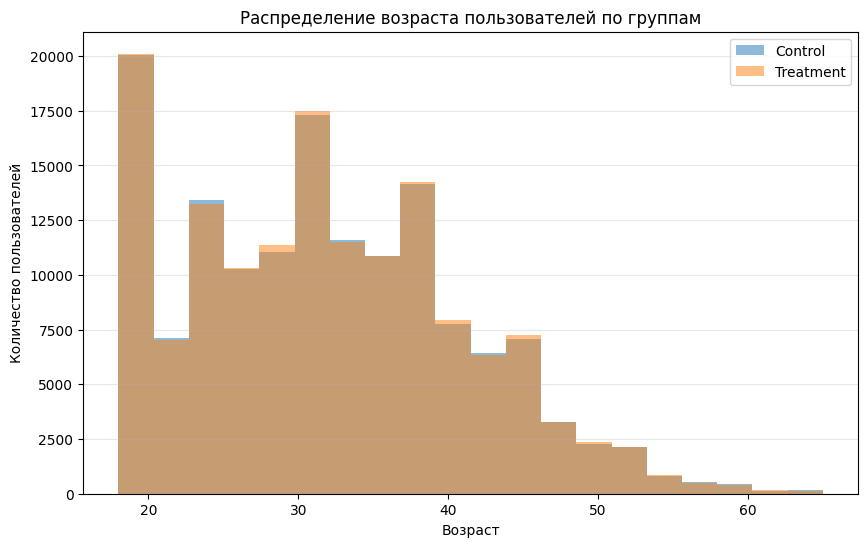

In [18]:
import matplotlib.pyplot as plt

# Гистограмма возраста: две группы на одном графике с прозрачностью для наглядного сравнения
plt.figure(figsize=(10, 6))

# Возраст пользователей контрольной группы
plt.hist(
    df[df['group'] == 'control']['age'],
    bins=20,
    alpha=0.5,
    label='Control'
)

# Возраст пользователей тестовой группы
plt.hist(
    df[df['group'] == 'treatment']['age'],
    bins=20,
    alpha=0.5,
    label='Treatment'
)

# Подписи и оформление
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.title('Распределение возраста пользователей по группам')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

#### Статистическая проверка баланса по возрасту

Описательная статистика и гистограмма показывают почти одинаковые распределения возраста, но для полноты проверки дополнительно применяются формальные тесты:

- **Welch t-test** — сравнение средних (не требует равенства дисперсий);
- **Mann–Whitney U** — непараметрическое сравнение распределений;
- **Kolmogorov–Smirnov** — проверка равенства функций распределения целиком;
- **Standardized Mean Difference (SMD)** — размер различия в единицах стандартного отклонения. Правило: |SMD| < 0.1 считается хорошим балансом.

При такой большой выборке (~294 тыс. пользователей) даже ничтожные различия могут дать маленький p-value, поэтому оценивается не только p-value, но и SMD.

In [ ]:
# Формальная проверка баланса по возрасту: параметрический, непараметрический и другие тесты
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

# Возраст пользователей в каждой группе
age_control = df.loc[df['group'] == 'control', 'age']
age_treatment = df.loc[df['group'] == 'treatment', 'age']

# Welch t-test — сравнение средних (equal_var=False: не требуется равенство дисперсий)
t_stat, t_p = ttest_ind(age_treatment, age_control, equal_var=False)
# Mann–Whitney — сравнение распределений без предположения о нормальности
u_stat, u_p = mannwhitneyu(age_treatment, age_control, alternative='two-sided')
# Колмогоров–Смирнов — сравнение функций распределения целиком
ks_stat, ks_p = ks_2samp(age_treatment, age_control)

# SMD — разница средних в единицах стандартного отклонения (|SMD| < 0.1 — хороший баланс)
pooled_std = np.sqrt((age_control.var(ddof=1) + age_treatment.var(ddof=1)) / 2)
smd = (age_treatment.mean() - age_control.mean()) / pooled_std

print(f'Welch t-test:   t = {t_stat:.4f}, p-value = {t_p:.4f}')
print(f'Mann-Whitney U: U = {u_stat:,.0f}, p-value = {u_p:.4f}')
print(f'KS-test:        D = {ks_stat:.4f}, p-value = {ks_p:.4f}')
print(f'SMD (age):      {smd:.4f}')

# Автоматический вывод: если все тесты не значимы, группы сбалансированы
if min(t_p, u_p, ks_p) > 0.05:
    print('Вывод: статистически значимых различий по возрасту нет — группы сбалансированы.')
else:
    # При значимом различии оценивается его практический размер по SMD
    print(f'Вывод: есть статистически значимое различие; практический размер различия |SMD| = {abs(smd):.3f} '
          f'({"пренебрежимо мал" if abs(smd) < 0.1 else "требует внимания"}).')

**Результат.** Все три теста не выявили различий по возрасту: Welch t-test p = 0.338, Mann–Whitney p = 0.332, KS-тест p = 0.527. SMD = 0.0035 — на два порядка ниже порога 0.1. Группы сбалансированы по возрасту.

### Итоги проверки корректности распределения пользователей

Перед оценкой эффективности новой версии страницы необходимо убедиться, что экспериментальные группы сформированы корректно и сопоставимы между собой.

Это важно, поскольку A/B-тест предполагает, что различия в целевой метрике между `control` и `treatment` должны быть обусловлены именно воздействием эксперимента, а не различиями в составе пользователей или ошибками при распределении.

На данном этапе были проверены:

1. соответствие экспериментальной группы и версии страницы;
2. соотношение размеров контрольной и тестовой групп;
3. распределение пользователей по полу;
4. распределение пользователей по типу устройства;
5. распределение пользователей по странам;
6. распределение пользователей по возрасту.

##### 1. Проверка соответствия группы и версии страницы

Сначала было проверено, соответствует ли значение `landing_page` экспериментальной группе.

Ожидаемая схема эксперимента:

- `control` → `old_page`;
- `treatment` → `new_page`.

По результатам проверки все пользователи контрольной группы получили `old_page`, а все пользователи тестовой группы — `new_page`.

Таким образом, несоответствий между экспериментальной группой и вариантом страницы не обнаружено.

##### 2. Проверка соотношения размеров групп

Далее было проверено, соответствует ли фактическое распределение пользователей ожидаемому соотношению 50/50.

Фактическое распределение:

- `control` — 146 926 пользователей;
- `treatment` — 147 552 пользователя.

Для проверки использован χ²-тест на соответствие.

Результат:

- χ² = 1.3307;
- p-value = 0.2487.

Так как `p-value > 0.05`, нет оснований отвергать гипотезу о соответствии распределения пользователей ожидаемому соотношению 50/50.

Следовательно, статистически значимого нарушения распределения пользователей между группами не обнаружено.

##### 3. Проверка категориальных характеристик пользователей

Для оценки сопоставимости групп были рассмотрены `gender`, `device_type` и `location`.

По описательной статистике распределения данных признаков между группами практически совпадают.

Для статистической проверки был использован χ²-тест независимости.

Полученные результаты:

| Признак | χ² | p-value |
|---|---:|---:|
| `gender` | 1.6306 | 0.4425 |
| `device_type` | 4.0338 | 0.1331 |
| `location` | 2.3099 | 0.8891 |

Для всех трёх признаков `p-value > 0.05`.

Следовательно, статистически значимых различий в распределении пользователей между `control` и `treatment` по полу, типу устройства и стране не обнаружено.

##### 4. Проверка возраста пользователей

Возраст был рассмотрен отдельно как числовой признак.

Описательная статистика:

| Группа | Количество | Среднее | Медиана | Std | Min | Max |
|---|---:|---:|---:|---:|---:|---:|
| Control | 146 926 | 31.89 | 31 | 9.25 | 18 | 65 |
| Treatment | 147 552 | 31.92 | 32 | 9.25 | 18 | 65 |

Разница между средними значениями составляет всего 0.03 года.

Визуальный анализ распределения возраста также показывает, что распределения `control` и `treatment` практически полностью совпадают. Выраженного смещения одной группы относительно другой не наблюдается. Дополнительно возраст проверен статистически (Welch t-test, Mann–Whitney, KS-тест и SMD) — p-value 0.34, 0.33 и 0.53 соответственно, SMD = 0.0035 — значимых различий нет.

Поэтому на основании описательной статистики и визуального анализа существенных различий в возрастном составе групп не обнаружено.

#### Итоговый вывод

Проведённая проверка не выявила признаков нарушения корректности экспериментального распределения.

Контрольная и тестовая группы:

- корректно связаны с соответствующими версиями страницы;
- не имеют статистически значимого отклонения от ожидаемого соотношения 50/50;
- сопоставимы по полу;
- сопоставимы по типу устройства;
- имеют практически одинаковое географическое распределение;
- имеют сходное распределение возраста.

Таким образом, на данном этапе нет очевидных признаков систематического дисбаланса между экспериментальными группами.

Это позволяет перейти к следующему этапу анализа — исследованию поведения пользователей и основных продуктовых метрик, а затем к оценке влияния новой версии страницы на конверсию и выручку.

#### 1. Общая конверсия

Conversion Rate (CR) — доля пользователей, совершивших целевое действие.

В датасете признак `converted` принимает значения:

- `0` — пользователь не совершил конверсию;
- `1` — пользователь совершил конверсию.

Далее рассчитываются количество пользователей, количество конверсий и общая Conversion Rate.

In [19]:
# Общая конверсия по всей выборке
total_users = df['user_id'].nunique()   # число уникальных пользователей
conversions = df['converted'].sum()     # число конверсий (сумма единиц)
conversion_rate = df['converted'].mean()  # доля конверсий = CR

print(f'Всего пользователей: {total_users:,}')
print(f'Количество конверсий: {conversions:,}')
print(f'Conversion Rate: {conversion_rate:.2%}')

Всего пользователей: 294,478
Количество конверсий: 43,928
Conversion Rate: 14.92%


В анализируемой выборке 294 478 пользователей, из которых 43 928 совершили целевое действие.
Общая конверсия составляет 14.92%, то есть примерно 15 из 100 пользователей совершили конверсию.

#### 2. Поведение пользователей в зависимости от конверсии

Необходимо рассмотреть две характеристики:
- `session_duration` — длительность пользовательской сессии;
- `pages_visited` — количество просмотренных страниц.

In [20]:
# Сравнение поведения пользователей с конверсией и без неё:
# среднее, медиана и стандартное отклонение для длительности сессии и числа просмотренных страниц
df.groupby('converted')[['session_duration', 'pages_visited']].agg(
    ['mean', 'median', 'std']
).round(2)

session_duration              pages_visited             
                      mean median   std          mean median   std
converted                                                         
0                      5.0   4.99  1.98          4.02    4.0  1.97
1                      5.0   4.99  1.99          4.03    4.0  1.96

In [ ]:
# Boxplot поведенческих метрик: сравнение пользователей без конверсии и с конверсией
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, title in zip(axes, ['session_duration', 'pages_visited'],
                          ['Длительность сессии', 'Количество просмотренных страниц']):
    # Два набора значений: converted = 0 и converted = 1 (выбросы скрыты для читаемости)
    data = [df.loc[df['converted'] == 0, col], df.loc[df['converted'] == 1, col]]
    ax.boxplot(data, showfliers=False)

    # Подписи категорий вместо номеров 1 и 2
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Без конверсии (0)', 'С конверсией (1)'])
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

В рамках описательного анализа выраженной связи между конверсией и длительностью сессии или количеством просмотренных страниц не наблюдается.

#### 3. Конверсия в зависимости от типа устройства

Необходимо проверить, отличается ли конверсия пользователей в зависимости от используемого устройства.

In [21]:
# Конверсия по типам устройств: число пользователей, число конверсий и CR
device_conversion = (
    df.groupby('device_type')['converted']
      .agg(['count', 'sum', 'mean'])      # count — пользователи, sum — конверсии, mean — доля конверсий
      .rename(columns={
          'count': 'users',
          'sum': 'conversions',
          'mean': 'conversion_rate'
    })
)

# Перевод CR из доли в проценты
device_conversion['conversion_rate'] *= 100

device_conversion.round(2)

,users,conversions,conversion_rate
device_type,,,
Desktop,176692,26529,15.01
Mobile,103093,15206,14.75
Tablet,14693,2193,14.93


Наибольшая конверсия наблюдается у пользователей Desktop — 15.01%, а наименьшая у пользователей Mobile — 14.75%. Разница между максимальным и минимальным значением составляет всего 0.26 процентного пункта.

Конверсия пользователей Tablet составляет 14.93% и также практически не отличается от остальных групп.

Таким образом, на уровне описательного анализа выраженной зависимости конверсии от типа устройства не наблюдается. Существенного различия в конверсии между Desktop, Mobile и Tablet не видно.

#### 4. Конверсия в зависимости от страны

Нужно исследовать, отличается ли конверсия пользователей в зависимости от их страны.

Для каждой страны необходимо рассчитать:

- количество пользователей;
- количество конверсий;
- Conversion Rate.

In [22]:
# Конверсия по странам: число пользователей, число конверсий и CR
location_conversion = (
    df.groupby('location')['converted']
      .agg(['count', 'sum', 'mean'])      # count — пользователи, sum — конверсии, mean — доля конверсий
      .rename(columns={
          'count': 'users',
          'sum': 'conversions',
          'mean': 'conversion_rate'
      })
)

# Перевод CR из доли в проценты
location_conversion['conversion_rate'] *= 100

# Сортировка от наибольшей конверсии к наименьшей
location_conversion.sort_values(
    'conversion_rate',
    ascending=False
).round(2)

,users,conversions,conversion_rate
location,,,
Canada,29241,4404,15.06
India,59014,8864,15.02
Australia,14587,2178,14.93
UK,44217,6597,14.92
US,88342,13159,14.90
Pakistan,29600,4409,14.90
Germany,29477,4317,14.65


Наибольшая конверсия наблюдается в Canada — 15.06%, а наименьшая в Germany — 14.65%. Разница между максимальным и минимальным значением составляет 0.41 процентного пункта.

Для остальных стран Conversion Rate находится в диапазоне примерно от 14.90% до 15.02%.

Таким образом, на уровне описательного анализа выраженных географических различий в конверсии не наблюдается. Страна пользователя не показывает заметного влияния на Conversion Rate в рассматриваемой выборке.


In [ ]:
# Общая конверсия по выборке — линия сравнения на графиках
overall_cr = df['converted'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})

# Что отображается: (ось, данные, заголовок); страны отсортированы по убыванию CR
plots = [
    (axes[0], device_conversion['conversion_rate'], 'Conversion Rate по типу устройства'),
    (axes[1], location_conversion['conversion_rate'].sort_values(ascending=False), 'Conversion Rate по странам'),
]

for ax, series, title in plots:
    # Столбцы CR с подписями значений
    series.plot(kind='bar', ax=ax, color='#2b7de9', width=0.7)
    ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=9)

    # Пунктирная линия — общий CR по выборке
    cr_line = ax.axhline(overall_cr, color='#e26d5c', linestyle='--', linewidth=1, label=f'Общий CR: {overall_cr:.2f}%')

    # Оформление графика
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Conversion Rate, %')
    ax.set_ylim(0, 20)   # ось от нуля, чтобы не преувеличивать малые различия
    ax.tick_params(axis='x', rotation=0)
    ax.legend(handles=[cr_line])
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### 5. Анализ выручки

Помимо конверсии, для продукта важна денежная составляющая пользовательского поведения.
Поэтому дополнительно нужно рассмотреть:

- общую выручку;
- среднюю выручку на одного пользователя (ARPU);
- среднюю сумму покупки среди конвертировавшихся пользователей (AOV).

In [23]:
# Общая выручка: сумма всех покупок
total_revenue = df['purchase_amount'].sum()

# ARPU — средняя выручка на одного пользователя (нулевые покупки входят в расчёт)
arpu = df['purchase_amount'].mean()

# AOV — средний чек только среди тех, кто совершил конверсию
aov = df.loc[df['converted'] == 1, 'purchase_amount'].mean()

print(f'Общая выручка: {total_revenue:,.2f}')
print(f'ARPU: {arpu:,.2f}')
print(f'AOV: {aov:,.2f}')

Общая выручка: 1,652,165.91
ARPU: 5.61
AOV: 37.61


Общая выручка пользователей в выборке составляет 1 652 165.91.

Средняя выручка на одного пользователя (ARPU) составляет 5.61, тогда как средняя сумма покупки среди пользователей, совершивших конверсию (AOV), составляет 37.61.

Значительное отличие между ARPU и AOV связано с тем, что большинство пользователей не совершает покупку и имеет `purchase_amount = 0`.

In [ ]:
# Суммы покупок только у пользователей, совершивших конверсию
buyers = df.loc[df['converted'] == 1, 'purchase_amount']

# Гистограмма с линиями среднего и медианы: разрыв между ними показывает асимметрию распределения
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(buyers, bins=50, color='#2b7de9', alpha=0.85)
ax.axvline(buyers.mean(), color='#e26d5c', linestyle='--', label=f'Среднее: {buyers.mean():.2f}')
ax.axvline(buyers.median(), color='black', linestyle=':', label=f'Медиана: {buyers.median():.2f}')

# Подписи и оформление
ax.set_title('Распределение суммы покупки среди покупателей')
ax.set_xlabel('purchase_amount')
ax.set_ylabel('Количество покупателей')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

Распределение суммы покупки скошено вправо: медиана (около 33) ниже среднего (около 38), а максимальная покупка достигает 269. Из-за такой асимметрии при сравнении групп по выручке в ноутбуке 02 используется bootstrap и непараметрический тест.

In [ ]:
# Проверка допущения: покупка (purchase_amount > 0) совершается только при converted = 1
# Обе проверки должны вернуть 0: тогда AOV корректно интерпретируется как средний чек покупателей
print('purchase_amount > 0 при converted = 0:', ((df['purchase_amount'] > 0) & (df['converted'] == 0)).sum())
print('purchase_amount = 0 при converted = 1:', ((df['purchase_amount'] == 0) & (df['converted'] == 1)).sum())

Эта проверка нужна, чтобы корректно интерпретировать AOV: если конверсия и покупка полностью совпадают, то AOV — это средняя сумма покупки среди покупателей, а ARPU = CR × AOV.

Сравнение выручки, ARPU и AOV **между группами control и treatment** выполняется в ноутбуке `02_ab_test_analysis`.